# Notebook to analyze Chromatin deconvolutions of YL Rep2

In [2]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [3]:
import os
from src.deconvolution_model import Model

# TODO: Rethink pathing of the deconvolution models, etc...
# combine cell cycle and deconvolution repositories..
model_path = ('../deconvolution-project/saved_output/2023-10-06_yl_rep2_chrom_small_prom_rg1_sigma0_11/'\
              'wt2_rg1_test_sigma0.label')
parentdir = '../deconvolution-project/saved_output/2023-10-06_yl_rep2_chrom_small_prom_rg1_sigma0_11/'
configpath = ('../deconvolution-project/saved_output/2023-10-06_yl_rep2_chrom_small_prom_rg1_sigma0_11/'\
              'DeconvYLRep2ChromSmallProm.matlab')

model = Model(model_path, parentdir, configpath)


In [4]:
ptrs = model.calculate_ptrs()

In [5]:
from src.sgd import read_sgd_genes

sgd_genes = read_sgd_genes()
gene_ptrs = model.ptrs.join(sgd_genes[['gene']])

model.ptrs.index.name = 'orf_name'
model.ptrs.to_csv('output/ptrs_yl_rep2_small_prom_2023-10-06.csv')

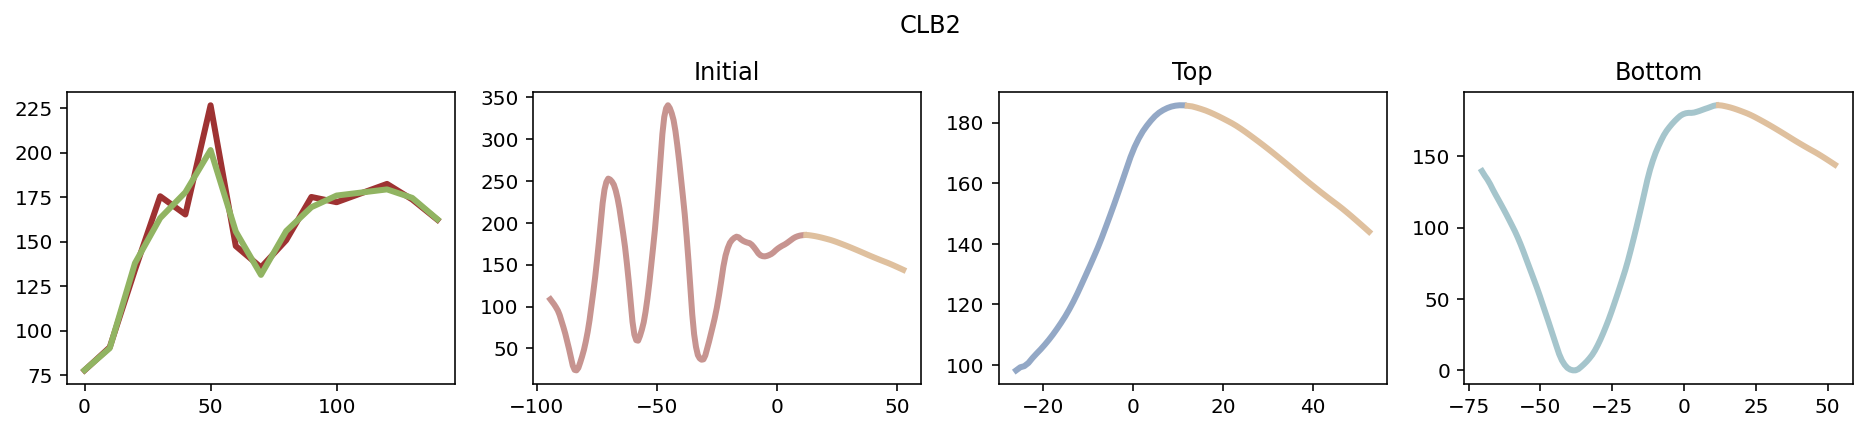

In [6]:
# Now we want to plot the deconvolved curves with the subinterval phase curves
gene_name = 'CLB2'
model.plot_deconvolved_gene(gene_name, model.deconv_f, model.deconv_g)

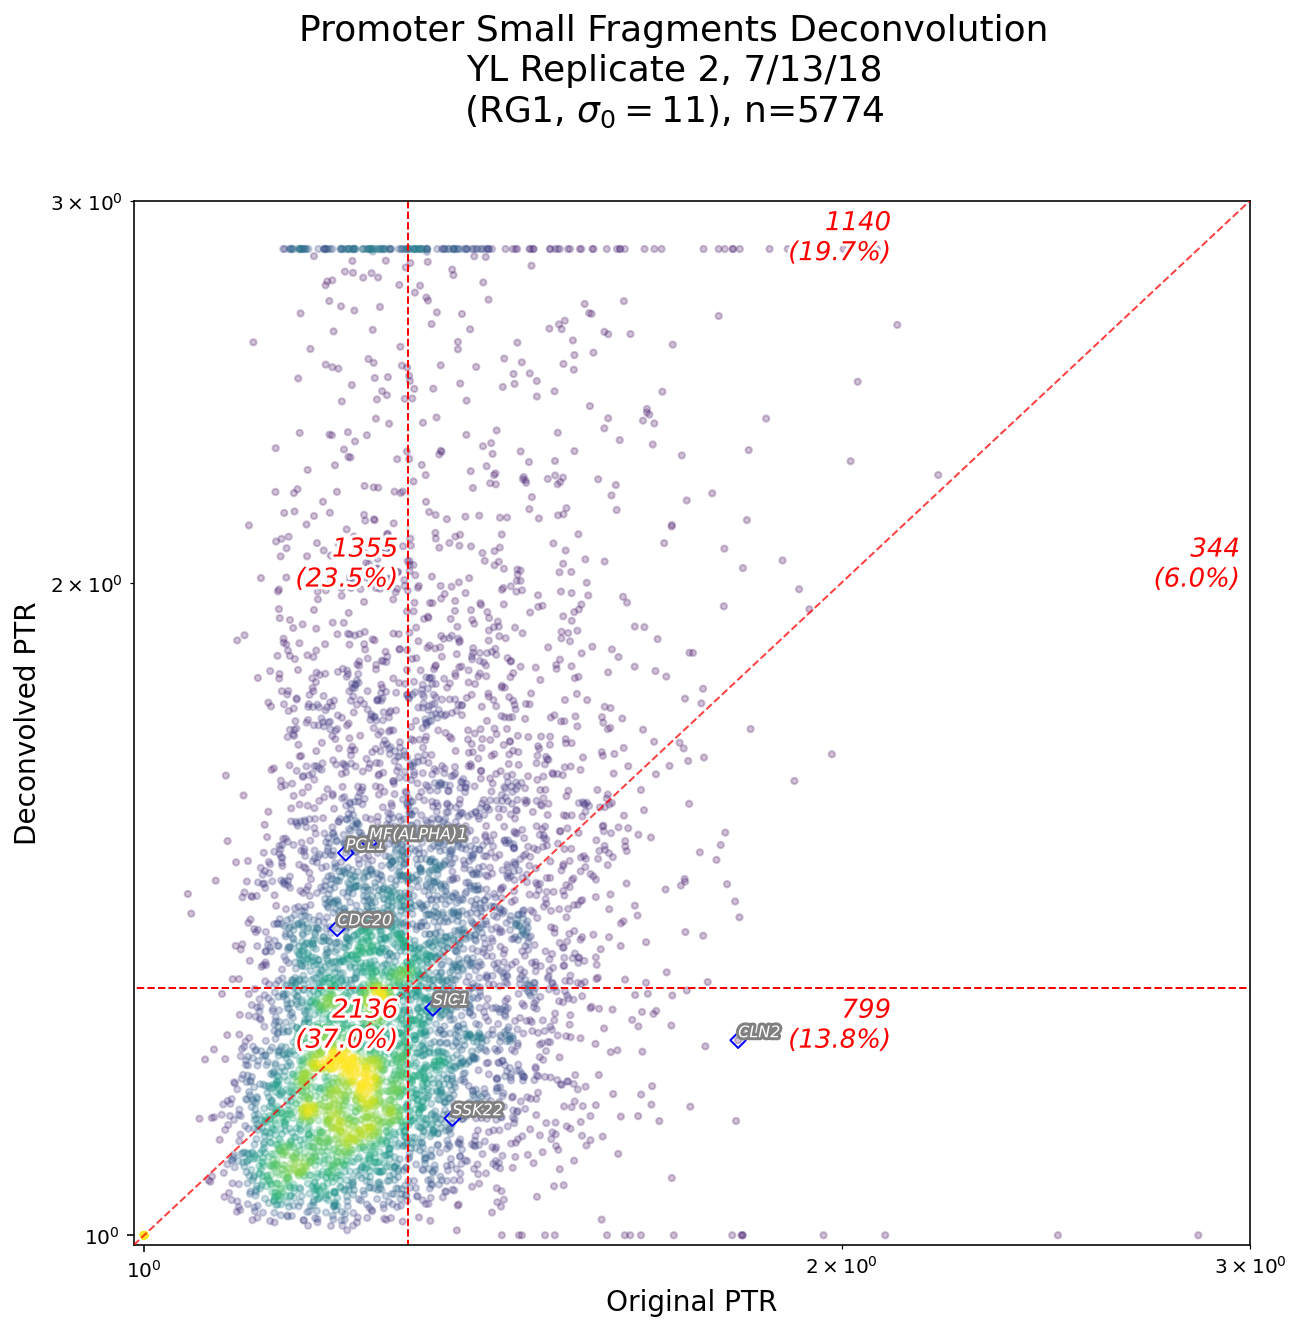

In [9]:
from src.deconvolution_model import plotting_gene_set
model.plot_ptrs_chromatin(plotting_gene_set(), 
                          "Promoter Small Fragments Deconvolution\nYL Replicate 2, 7/13/18\n"
                          "(RG1, $\sigma_0=11$)")
ax = plt.gca()